In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("cleaned_data.csv")

In [19]:
df.columns

Index(['Student Code', 'State', 'Started on', 'Completed', 'Time taken',
       'Grade/10.00', 'Q. 1 /2.00', 'Q. 2 /2.00', 'Q. 3 /2.00', 'Q. 4 /2.00',
       'Q. 5 /2.00', 'quiz', 'grade', 'time_seconds', 'time_minutes', 'q1',
       'q2', 'q3', 'q4', 'q5', 'attempt_num'],
      dtype='object')

In [20]:
df.head()

,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,...,quiz,grade,time_seconds,time_minutes,q1,q2,q3,q4,q5,attempt_num
0,1,Finished,14 March 2022 6:55 AM,14 March 2022 7:03 AM,7 mins 25 secs,6.0,0.00,2.00,2.00,2.00,...,1,6.0,445,7.416667,0.0,2.0,2.0,2.0,0.0,1
1,1,Finished,14 March 2022 7:11 AM,14 March 2022 7:12 AM,1 min 4 secs,10.0,2.00,2.00,2.00,2.00,...,1,10.0,64,1.066667,2.0,2.0,2.0,2.0,2.0,2
2,1,Finished,14 March 2022 2:56 PM,14 March 2022 3:01 PM,4 mins 55 secs,6.0,0.00,2.00,2.00,2.00,...,2,6.0,295,4.916667,0.0,2.0,2.0,2.0,0.0,1
3,1,Finished,14 March 2022 3:06 PM,14 March 2022 3:10 PM,4 mins 21 secs,6.0,2.00,2.00,0.00,0.00,...,3,6.0,261,4.350000,2.0,2.0,0.0,0.0,2.0,1
4,2,Finished,14 March 2022 5:42 PM,14 March 2022 6:01 PM,19 mins 33 secs,4.0,0.00,2.00,2.00,0.00,...,1,4.0,1173,19.550000,0.0,2.0,2.0,0.0,0.0,1


In [21]:
attempt_counts = df['attempt_num'].value_counts().sort_index()
print("Counts of attempts:\n", attempt_counts)

Counts of attempts:
 attempt_num
1    19428
2     7834
3     2783
4      989
5      276
6       20
7        4
Name: count, dtype: int64


**H1 : Students who take longer to complete the quiz tend to score higher.**

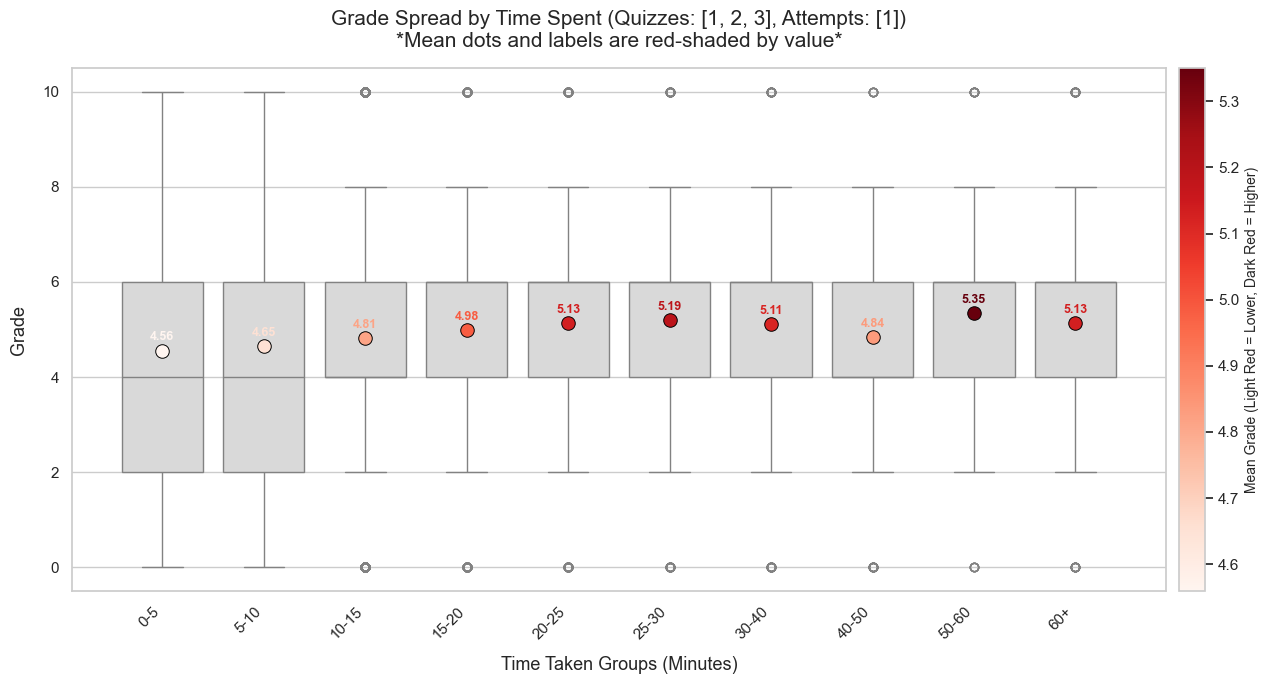

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

quizzes_to_include = [1, 2, 3]
attempts_to_include = [1]

filtered_df = df[
    df['quiz'].isin(quizzes_to_include) & df['attempt_num'].isin(attempts_to_include)
].copy()

bins = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, np.inf]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-40', '40-50', '50-60', '60+']
filtered_df['time_bin'] = pd.cut(filtered_df['time_minutes'], bins=bins, labels=labels)

# Mean grade per time bin for red-gradient mean markers
mean_by_bin = filtered_df.groupby('time_bin', observed=False)['grade'].mean().reindex(labels)
valid_means = mean_by_bin.dropna()

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=filtered_df,
    x='time_bin',
    y='grade',
    color='#d9d9d9'
 )

# Build a light->dark red scale where darker means higher mean grade
if not valid_means.empty:
    norm = plt.Normalize(valid_means.min(), valid_means.max())
    cmap = plt.cm.Reds

    for x, y in enumerate(mean_by_bin.values):
        if pd.notna(y):
            mean_color = cmap(norm(y))
            ax.scatter(x, y, s=95, color=mean_color, edgecolor='black', linewidth=0.7, zorder=4)
            ax.text(
                x, y + 0.15, f'{y:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=mean_color
            )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('Mean Grade (Light Red = Lower, Dark Red = Higher)', fontsize=10)

plt.title(
    f'Grade Spread by Time Spent (Quizzes: {quizzes_to_include}, Attempts: {attempts_to_include})\n'
    '*Mean dots and labels are red-shaded by value*',
    fontsize=15, pad=15
)
plt.xlabel('Time Taken Groups (Minutes)', fontsize=13, labelpad=10)
plt.ylabel('Grade', fontsize=13, labelpad=10)
plt.ylim(-0.5, 10.5)
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.savefig('grouped_boxplot_60min.png', dpi=300)
plt.show()

**H2 : Some questions are consistently harder than others**

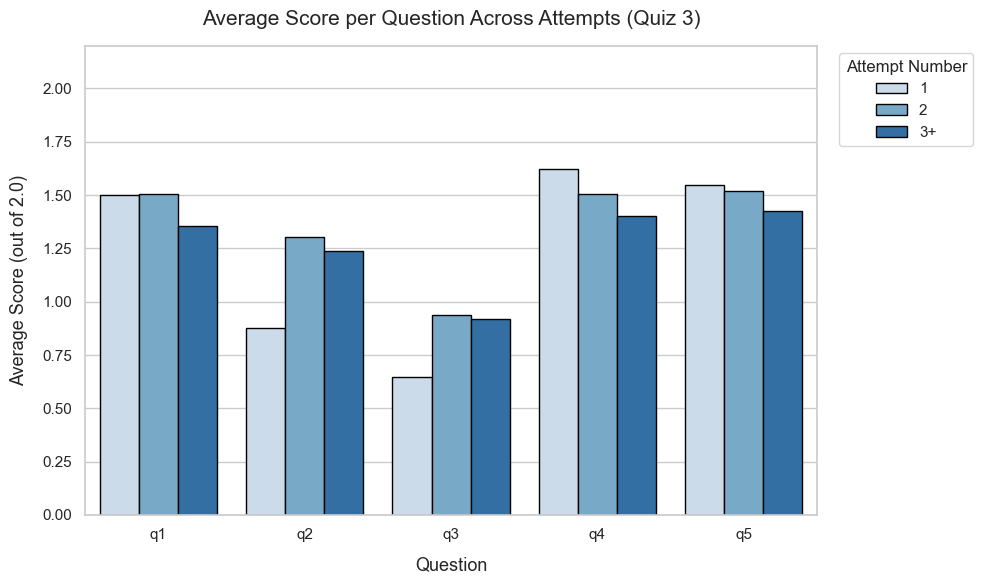

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('cleaned_data.csv')

# ==============================================
# --- CHANGE THIS VARIABLE FOR OTHER QUIZZES ---
QUIZ_NUMBER = 3
# ==============================================

# Filter data for the specific quiz
quiz_df = df[df['quiz'] == QUIZ_NUMBER].copy()

# Group attempts
quiz_df['attempt_group'] = quiz_df['attempt_num'].apply(lambda x: '1' if x == 1 else ('2' if x == 2 else '3+'))

# Calculate average scores
question_cols = ['q1', 'q2', 'q3', 'q4', 'q5']
summary = quiz_df.groupby('attempt_group')[question_cols].mean().reset_index()

# Melt data for grouped bar chart (restructures it for Seaborn)
melted_df = summary.melt(id_vars='attempt_group', value_vars=question_cols,
                         var_name='Question', value_name='Average Score')

# Ensure correct order of attempts in the legend/bars
melted_df['attempt_group'] = pd.Categorical(melted_df['attempt_group'], categories=['1', '2', '3+'], ordered=True)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# We use a sequential colormap ('Blues') because attempts are ordered (1 -> 2 -> 3+)
ax = sns.barplot(
    data=melted_df,
    x='Question',
    y='Average Score',
    hue='attempt_group',
    palette='Blues',
    edgecolor='black' # Improves separability
)

# Formatting spatial position and labels
plt.title(f'Average Score per Question Across Attempts (Quiz {QUIZ_NUMBER})', fontsize=15, pad=15)
plt.xlabel('Question', fontsize=13, labelpad=10)
plt.ylabel('Average Score (out of 2.0)', fontsize=13, labelpad=10)
plt.ylim(0, 2.2) # Max score is 2.0, adding slight padding for readability

# Move legend outside the plot so it doesn't cover any data
plt.legend(title='Attempt Number', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f'grouped_bar_quiz_{QUIZ_NUMBER}.png', dpi=300)
plt.show()

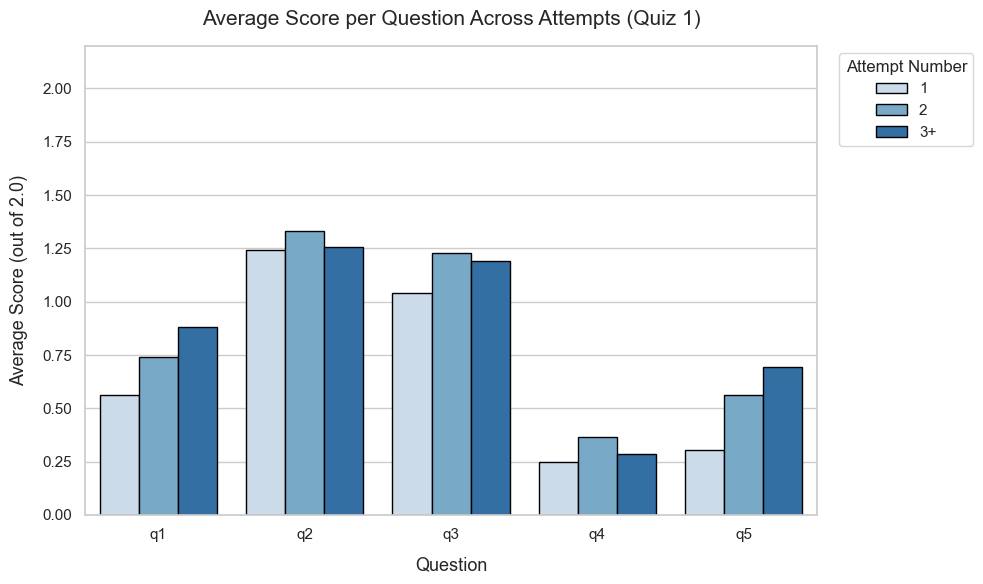

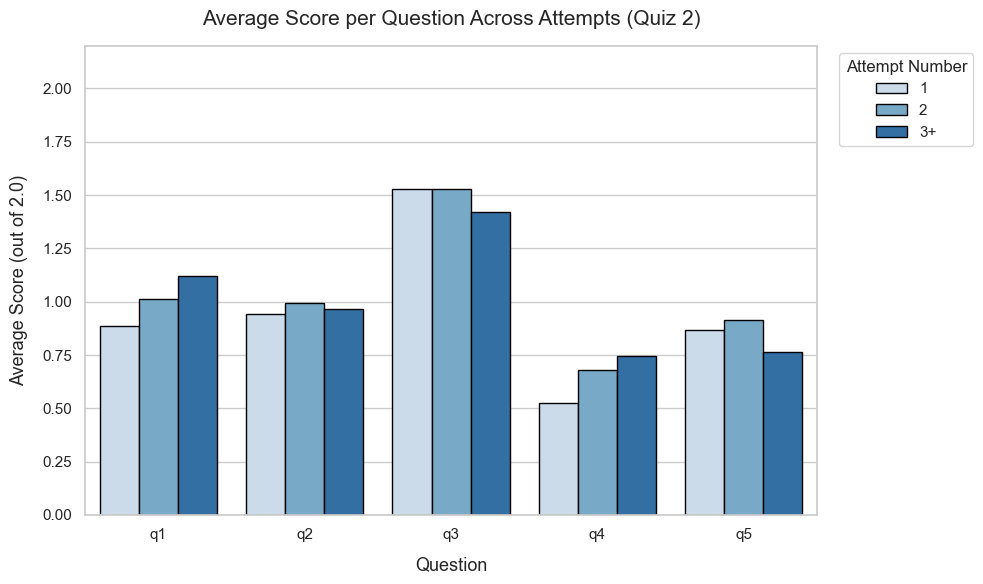

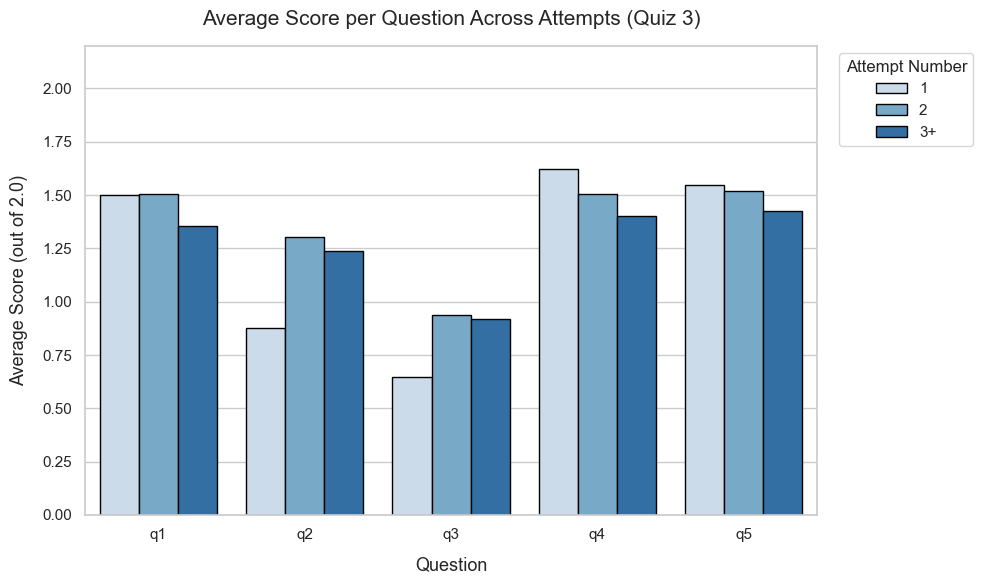

In [24]:
for QUIZ_NUMBER in range(1, 4):

    quiz_df = df[df['quiz'] == QUIZ_NUMBER].copy()

    if quiz_df.empty:
        print(f"Quiz {QUIZ_NUMBER}")
        continue

    quiz_df['attempt_group'] = quiz_df['attempt_num'].apply(lambda x: '1' if x == 1 else ('2' if x == 2 else '3+'))

    question_cols = ['q1', 'q2', 'q3', 'q4', 'q5']
    summary = quiz_df.groupby('attempt_group')[question_cols].mean().reset_index()

    melted_df = summary.melt(id_vars='attempt_group', value_vars=question_cols,
                             var_name='Question', value_name='Average Score')

    melted_df['attempt_group'] = pd.Categorical(melted_df['attempt_group'],
                                             categories=['1', '2', '3+'],
                                             ordered=True)

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        data=melted_df,
        x='Question',
        y='Average Score',
        hue='attempt_group',
        palette='Blues',
        edgecolor='black'
    )

    plt.title(f'Average Score per Question Across Attempts (Quiz {QUIZ_NUMBER})', fontsize=15, pad=15)
    plt.xlabel('Question', fontsize=13, labelpad=10)
    plt.ylabel('Average Score (out of 2.0)', fontsize=13, labelpad=10)
    plt.ylim(0, 2.2)

    plt.legend(title='Attempt Number', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(f'grouped_bar_quiz_{QUIZ_NUMBER}.png', dpi=300)
    plt.show()

**H3 : High-performing students consistently improve scores over multiple attempts, whereas low performers show erratic progress.**

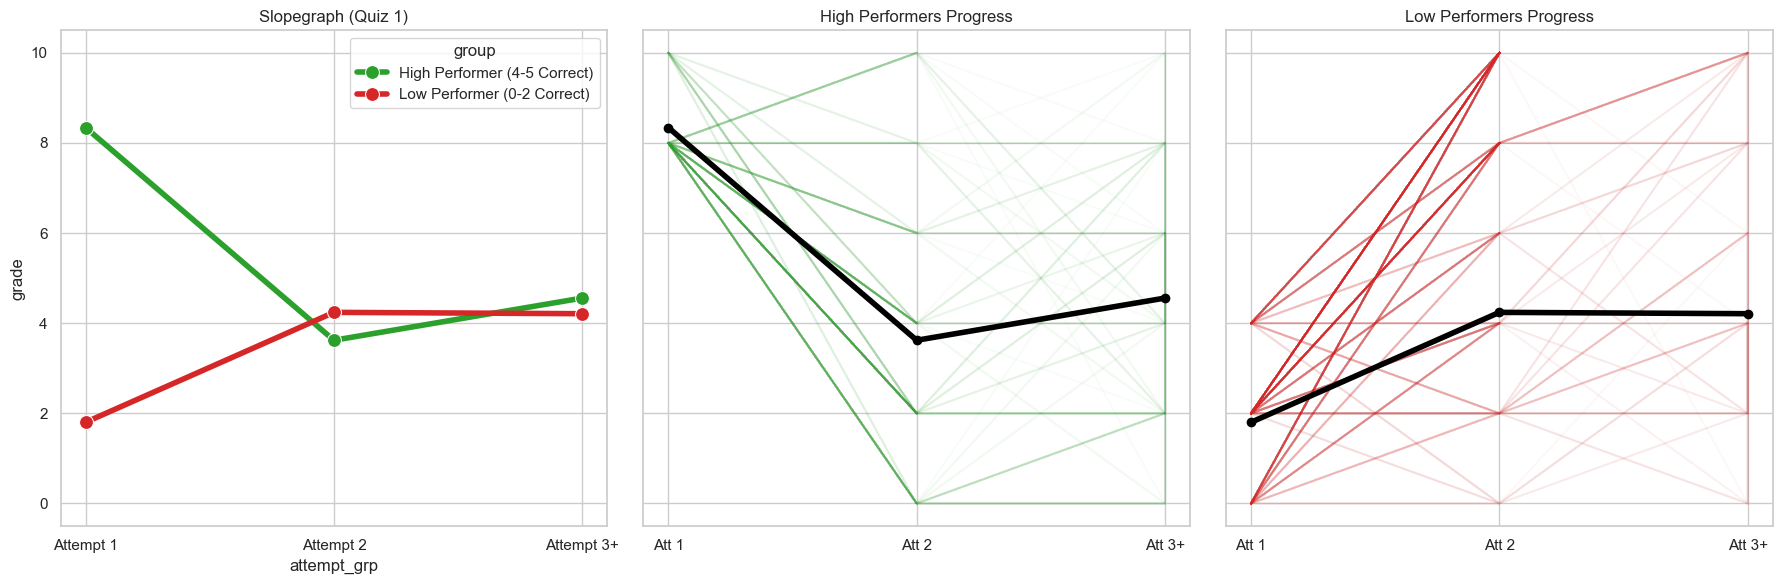

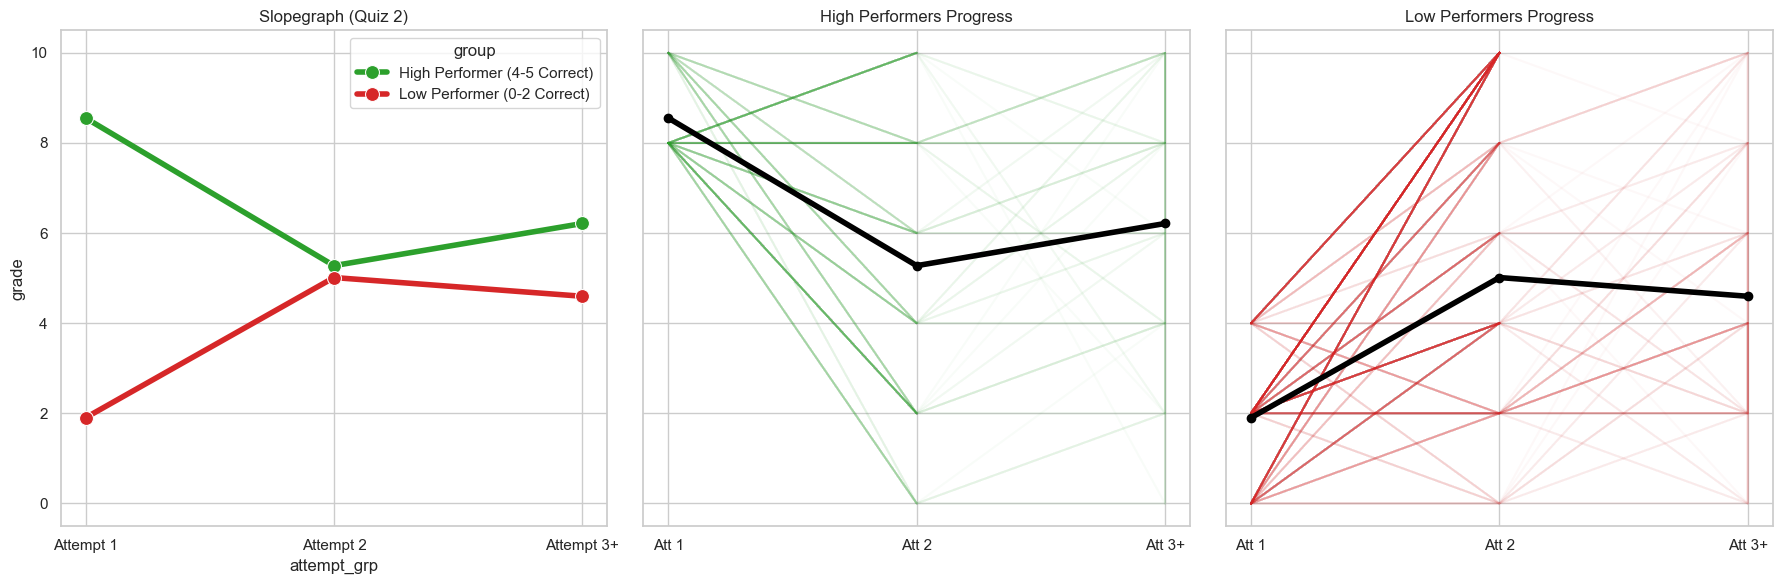

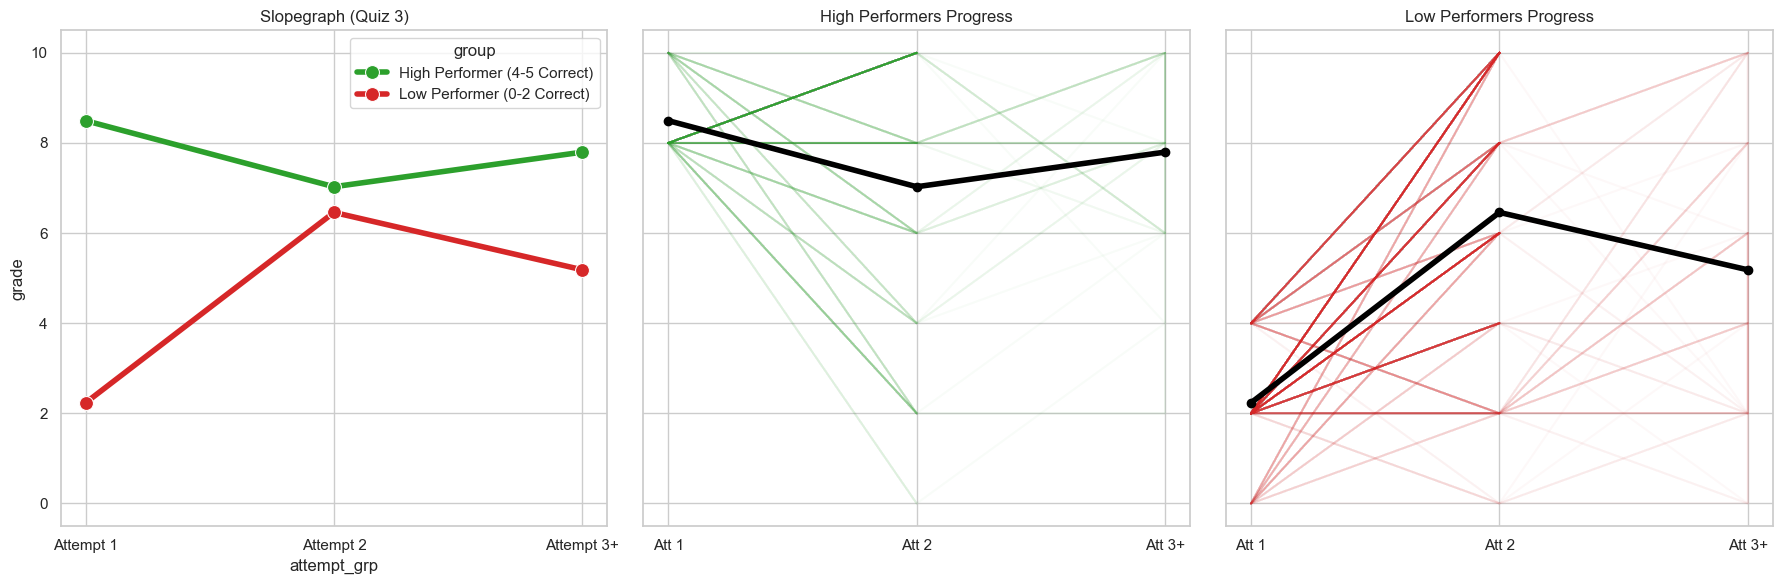

In [25]:
for QUIZ_NUMBER in range(1, 4):
    quiz_df = df[df['quiz'] == QUIZ_NUMBER].copy()

    if quiz_df.empty:
        continue

    quiz_df['attempt_num'] = quiz_df['attempt_num'].astype(int)
    student_counts = quiz_df.groupby('Student Code')['attempt_num'].max()
    multi_attempt_students = student_counts[student_counts >= 2].index
    multi_df = quiz_df[quiz_df['Student Code'].isin(multi_attempt_students)].copy()
    multi_df['attempt_grp'] = multi_df['attempt_num'].apply(lambda x: 3 if x >= 3 else x)

    attempt1_df = multi_df[multi_df['attempt_num'] == 1][['Student Code', 'grade']].set_index('Student Code')

    def categorize_student(grade):
        if grade >= 8.0: return 'High Performer (4-5 Correct)'
        elif grade <= 4.0: return 'Low Performer (0-2 Correct)'
        else: return 'Medium (3 Correct)'

    attempt1_df['group'] = attempt1_df['grade'].apply(categorize_student)
    analysis_df = multi_df.merge(attempt1_df[['group']], left_on='Student Code', right_index=True)
    plot_df = analysis_df[analysis_df['group'].isin(['High Performer (4-5 Correct)', 'Low Performer (0-2 Correct)'])].copy()
    avg_df = plot_df.groupby(['group', 'attempt_grp'])['grade'].mean().reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    sns.set_theme(style="whitegrid")
    palette = {'High Performer (4-5 Correct)': '#2ca02c', 'Low Performer (0-2 Correct)': '#d62728'}

    sns.lineplot(
        data=avg_df, x='attempt_grp', y='grade', hue='group',
        palette=palette, marker='o', linewidth=4, markersize=10, ax=axes[0]
    )
    axes[0].set_title(f'Slopegraph (Quiz {QUIZ_NUMBER})')
    axes[0].set_xticks([1, 2, 3])
    axes[0].set_xticklabels(['Attempt 1', 'Attempt 2', 'Attempt 3+'])
    axes[0].set_ylim(-0.5, 10.5)

    high_df = plot_df[plot_df['group'] == 'High Performer (4-5 Correct)']
    for student in high_df['Student Code'].unique()[:500]:
        student_data = high_df[high_df['Student Code'] == student]
        axes[1].plot(student_data['attempt_grp'], student_data['grade'], color=palette['High Performer (4-5 Correct)'], alpha=0.03)

    high_avg = avg_df[avg_df['group'] == 'High Performer (4-5 Correct)']
    axes[1].plot(high_avg['attempt_grp'], high_avg['grade'], color='black', linewidth=4, marker='o')
    axes[1].set_title('High Performers Progress')
    axes[1].set_xticks([1, 2, 3])
    axes[1].set_xticklabels(['Att 1', 'Att 2', 'Att 3+'])

    low_df = plot_df[plot_df['group'] == 'Low Performer (0-2 Correct)']
    for student in low_df['Student Code'].unique()[:500]:
        student_data = low_df[low_df['Student Code'] == student]
        axes[2].plot(student_data['attempt_grp'], student_data['grade'], color=palette['Low Performer (0-2 Correct)'], alpha=0.03)

    low_avg = avg_df[avg_df['group'] == 'Low Performer (0-2 Correct)']
    axes[2].plot(low_avg['attempt_grp'], low_avg['grade'], color='black', linewidth=4, marker='o')
    axes[2].set_title('Low Performers Progress')
    axes[2].set_xticks([1, 2, 3])
    axes[2].set_xticklabels(['Att 1', 'Att 2', 'Att 3+'])

    plt.tight_layout()
    plt.savefig(f'progress_analysis_quiz_{QUIZ_NUMBER}.png', dpi=300)
    plt.show()

H4 : More difficult questions take longer to answer, but higher-performing students
answer them faster than lower-performing students.

C:\Users\DASUN\AppData\Local\Temp\ipykernel_24356\881462897.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


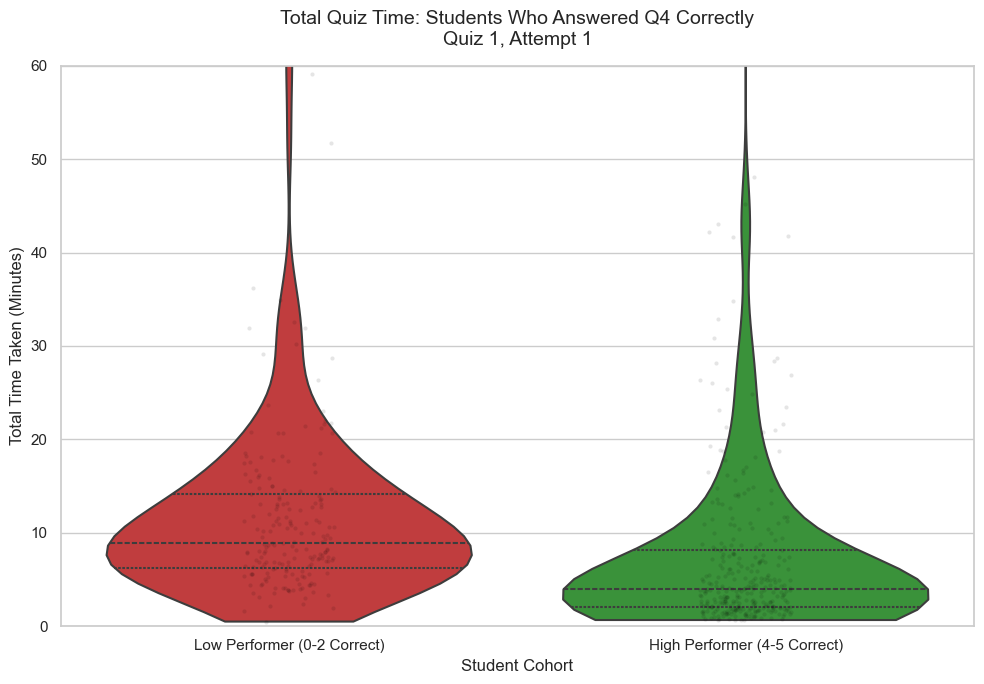

C:\Users\DASUN\AppData\Local\Temp\ipykernel_24356\881462897.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


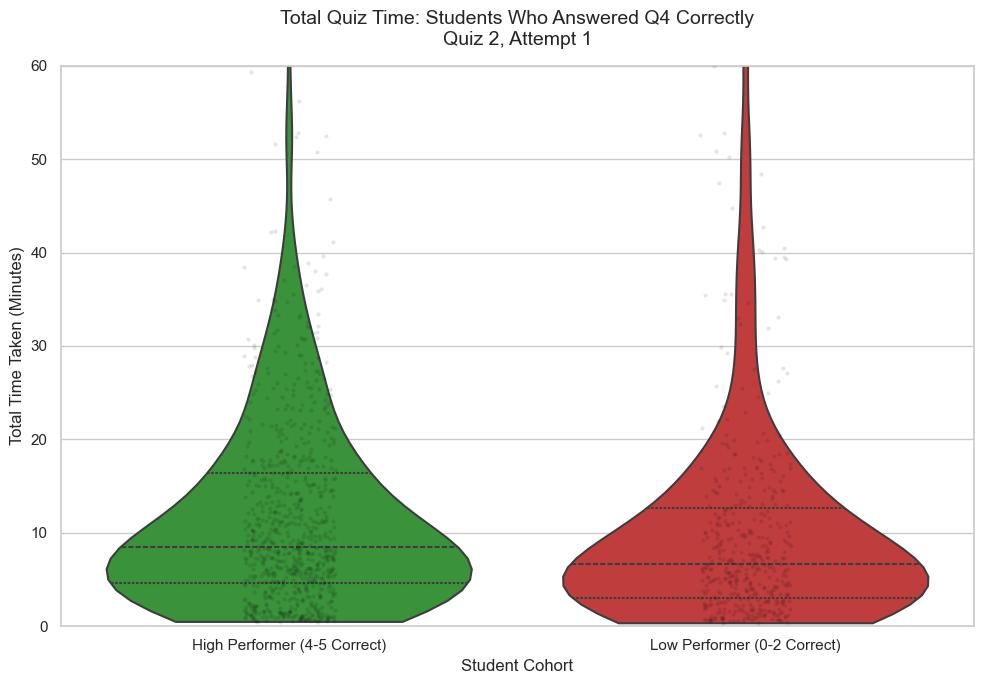

C:\Users\DASUN\AppData\Local\Temp\ipykernel_24356\881462897.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


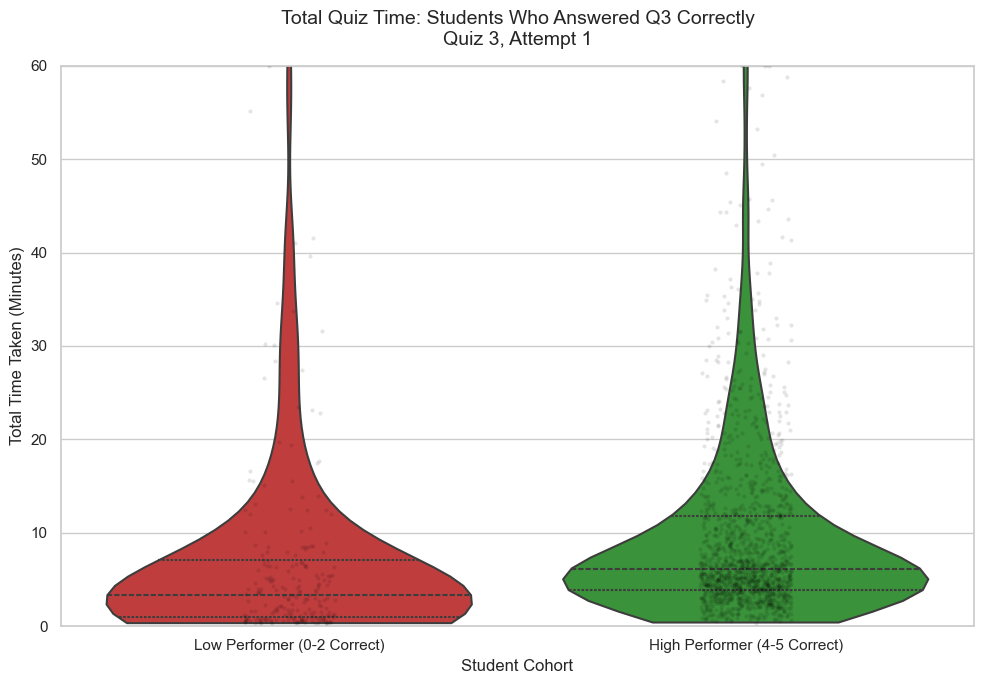

In [26]:
quiz_difficult_map = {
    1: 'q4',
    2: 'q4',
    3: 'q3'
}

for QUIZ_NUMBER, QUESTION_TO_ANALYZE in quiz_difficult_map.items():


    df1 = df[(df['attempt_num'] == 1) & (df['quiz'] == QUIZ_NUMBER)].copy()

    if df1.empty:
        continue

    def categorize(g):
        if g >= 8.0: return 'High Performer (4-5 Correct)'
        elif g <= 4.0: return 'Low Performer (0-2 Correct)'
        else: return 'Medium'

    df1['Performance Group'] = df1['grade'].apply(categorize)
    df_filtered = df1[df1['Performance Group'].isin(['High Performer (4-5 Correct)', 'Low Performer (0-2 Correct)'])]

    df_correct = df_filtered[df_filtered[QUESTION_TO_ANALYZE] == 2.0].copy()

    plt.figure(figsize=(10, 7))
    sns.set_theme(style="whitegrid")
    palette = {'High Performer (4-5 Correct)': '#2ca02c', 'Low Performer (0-2 Correct)': '#d62728'}

    sns.violinplot(
        data=df_correct,
        x='Performance Group',
        y='time_minutes',
        palette=palette,
        inner='quartile',
        linewidth=1.5,
        cut=0
    )

    sns.stripplot(
        data=df_correct,
        x='Performance Group',
        y='time_minutes',
        color='black',
        alpha=0.1,
        jitter=True,
        size=3
    )

    plt.title(f'Total Quiz Time: Students Who Answered {QUESTION_TO_ANALYZE.upper()} Correctly\nQuiz {QUIZ_NUMBER}, Attempt 1', fontsize=14, pad=15)
    plt.ylabel('Total Time Taken (Minutes)', fontsize=12)
    plt.xlabel('Student Cohort', fontsize=12)
    plt.ylim(0, 60)

    plt.tight_layout()
    plt.savefig(f'quiz_{QUIZ_NUMBER}_{QUESTION_TO_ANALYZE}_analysis.png', dpi=300)
    plt.show()

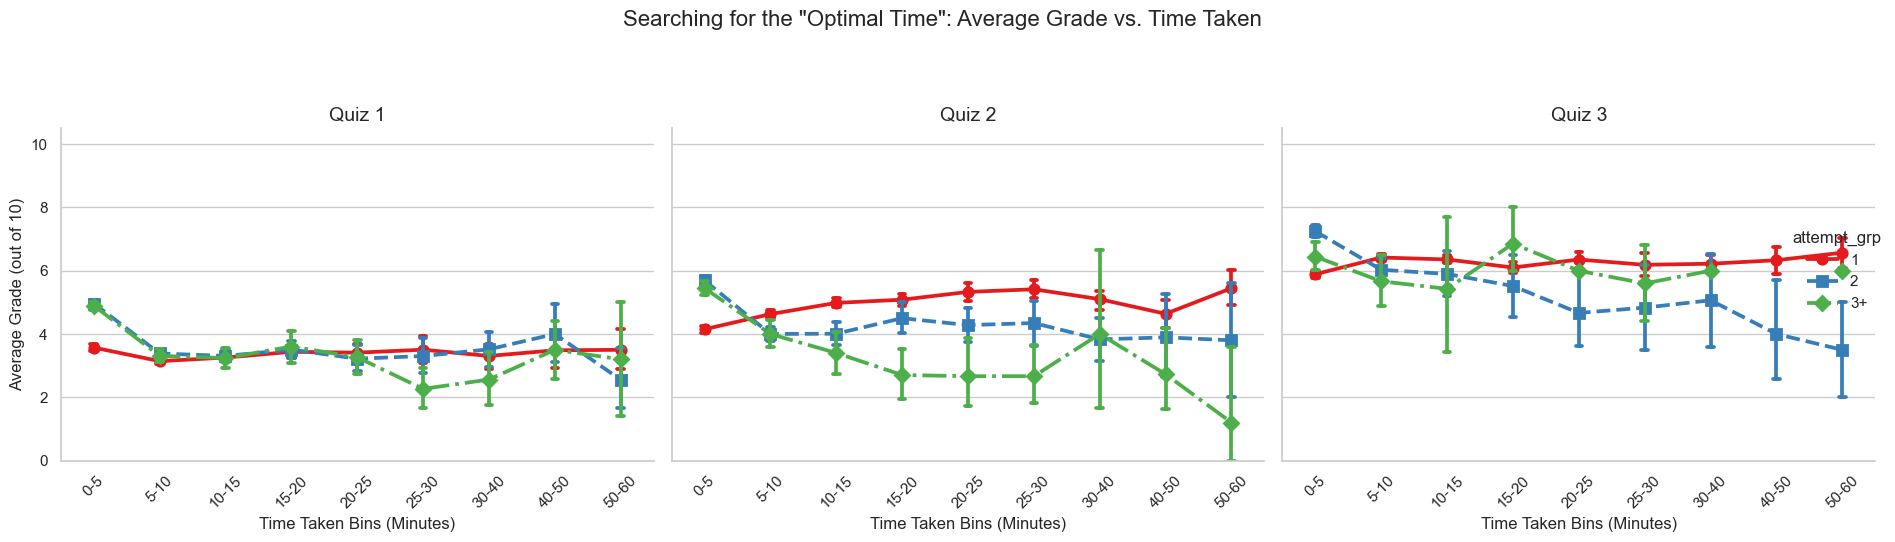

In [27]:


QUIZZES_TO_ANALYZE = [1, 2, 3]

df_q = df[df['quiz'].isin(QUIZZES_TO_ANALYZE)].copy()

df_q['attempt_grp'] = df_q['attempt_num'].apply(lambda x: '1' if x == 1 else ('2' if x == 2 else '3+'))

bins = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-40', '40-50', '50-60']
df_q['Time Bin (Minutes)'] = pd.cut(df_q['time_minutes'], bins=bins, labels=labels)

sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df_q,
    x='Time Bin (Minutes)',
    y='grade',
    hue='attempt_grp',
    col='quiz',
    kind='point',
    palette='Set1',
    height=5,
    aspect=1.2,
    markers=['o', 's', 'D'],
    linestyles=['-', '--', '-.'],
    errorbar=('ci', 95),
    capsize=0.1
)

g.fig.suptitle('Searching for the "Optimal Time": Average Grade vs. Time Taken', fontsize=16, y=1.08)
g.set_axis_labels("Time Taken Bins (Minutes)", "Average Grade (out of 10)")
g.set_titles("Quiz {col_name}", size=14)

for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, 10.5)

plt.tight_layout()
plt.savefig('optimal_time_juxtaposed_with_errorbars.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 2: Five Additional Hypotheses (Format-Robust)
The cells below reuse the notebook dataset (`df`) and first standardize column formats so the analysis still works even if column names or types vary.

In [28]:
import re

sns.set_theme(style="whitegrid")

# Optional SciPy support; fallback keeps notebook runnable even if scipy is unavailable
try:
    from scipy.stats import kruskal as _scipy_kruskal, spearmanr as _scipy_spearmanr
    SCIPY_AVAILABLE = True
except Exception:
    _scipy_kruskal = None
    _scipy_spearmanr = None
    SCIPY_AVAILABLE = False

def safe_spearmanr(x, y):
    if SCIPY_AVAILABLE:
        return _scipy_spearmanr(x, y)
    # Fallback: rho only (p-value not available without scipy)
    x_s = pd.Series(x, dtype="float64")
    y_s = pd.Series(y, dtype="float64")
    valid = x_s.notna() & y_s.notna()
    x_rank = x_s[valid].rank(method="average")
    y_rank = y_s[valid].rank(method="average")
    if len(x_rank) < 2:
        return np.nan, np.nan
    rho = np.corrcoef(x_rank.to_numpy(), y_rank.to_numpy())[0, 1]
    return float(rho), np.nan

def safe_kruskal(*groups):
    if SCIPY_AVAILABLE:
        return _scipy_kruskal(*groups)
    # Fallback: no non-parametric test without scipy
    return np.nan, np.nan

def _pick_col(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def _parse_time_to_seconds(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text in {"", "-"}:
        return np.nan

    # Accept both structured strings (e.g., "1 hour 3 mins") and numeric strings
    if re.fullmatch(r"\d+(\.\d+)?", text):
        return float(text)

    total = 0
    matches = re.findall(r"(\d+)\s*(day|days|hour|hours|min|mins|sec|secs)", text)
    for amount, unit in matches:
        n = int(amount)
        if "day" in unit:
            total += n * 86400
        elif "hour" in unit:
            total += n * 3600
        elif "min" in unit:
            total += n * 60
        elif "sec" in unit:
            total += n
    return float(total) if total > 0 else np.nan

def standardize_for_task2(df_input):
    x = df_input.copy()

    student_col = _pick_col(x.columns, ["Student Code", "student", "student_code"])

    quiz_col = _pick_col(x.columns, ["quiz", "Quiz"])

    grade_col = _pick_col(x.columns, ["grade", "Grade/10.00", "Grade"])

    attempt_col = _pick_col(x.columns, ["attempt_num", "attempt_no", "Attempt"])

    started_col = _pick_col(x.columns, ["Started on", "start_dt", "started_on", "Completed"])

    time_min_col = _pick_col(x.columns, ["time_minutes"])

    time_sec_col = _pick_col(x.columns, ["time_seconds", "time_sec"])

    time_taken_col = _pick_col(x.columns, ["Time taken", "time_taken"])


    if student_col is None or quiz_col is None or grade_col is None:
        raise ValueError("Dataset must contain student, quiz, and grade columns.")

    out = pd.DataFrame()
    out["student"] = pd.to_numeric(x[student_col], errors="coerce")
    out["quiz"] = pd.to_numeric(x[quiz_col], errors="coerce")
    out["grade"] = pd.to_numeric(x[grade_col], errors="coerce")

    if time_min_col is not None:
        out["time_sec"] = pd.to_numeric(x[time_min_col], errors="coerce") * 60.0
    elif time_sec_col is not None:
        out["time_sec"] = pd.to_numeric(x[time_sec_col], errors="coerce")
    elif time_taken_col is not None:
        out["time_sec"] = x[time_taken_col].map(_parse_time_to_seconds)
    else:
        out["time_sec"] = np.nan

    if started_col is not None:
        out["start_dt"] = pd.to_datetime(x[started_col], errors="coerce")
    else:
        out["start_dt"] = pd.NaT

    # Attempt handling: prefer existing attempt column; otherwise infer by start time
    if attempt_col is not None:
        out["attempt_no"] = pd.to_numeric(x[attempt_col], errors="coerce")
    else:
        out["attempt_no"] = np.nan

    out = out.dropna(subset=["student", "quiz", "grade"]).copy()
    out["student"] = out["student"].astype(int)
    out["quiz"] = out["quiz"].astype(int)

    if out["attempt_no"].isna().all():
        if out["start_dt"].notna().any():
            out = out.sort_values(["quiz", "student", "start_dt"])
        else:
            out = out.sort_values(["quiz", "student"])
        out["attempt_no"] = out.groupby(["quiz", "student"]).cumcount() + 1
    else:
        out["attempt_no"] = out["attempt_no"].fillna(
            out.groupby(["quiz", "student"]).cumcount() + 1
        )

    out["attempt_no"] = out["attempt_no"].astype(int)
    return out

task2_df = standardize_for_task2(df)
print(f"Task 2 standardized rows: {len(task2_df)}")
print(f"Task 2 students: {task2_df['student'].nunique()}")
if not SCIPY_AVAILABLE:
    print("SciPy not found: p-values for Spearman/Kruskal are shown as NaN, but visual analysis still runs.")
task2_df.head()

Task 2 standardized rows: 31334
Task 2 students: 6651
SciPy not found: p-values for Spearman/Kruskal are shown as NaN, but visual analysis still runs.


,student,quiz,grade,time_sec,start_dt,attempt_no
0,1,1,6.0,445.0,2022-03-14 06:55:00,1
1,1,1,10.0,64.0,2022-03-14 07:11:00,2
2,1,2,6.0,295.0,2022-03-14 14:56:00,1
3,1,3,6.0,261.0,2022-03-14 15:06:00,1
4,2,1,4.0,1173.0,2022-03-14 17:42:00,1


### Task 2 - Hypothesis 1
**Topic:** First-attempt performance vs retry behavior

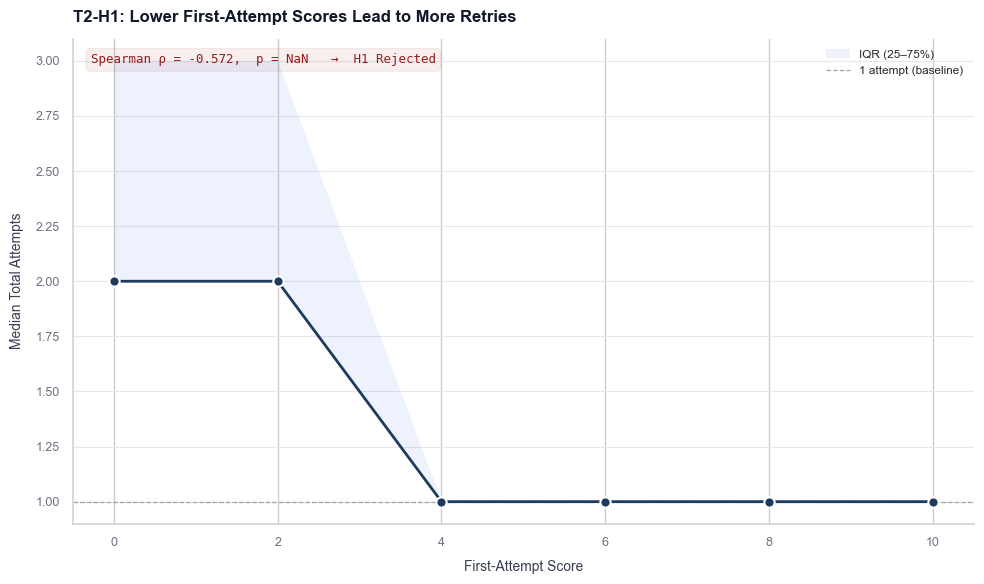

In [29]:
# ----- Task 2 - H1 -----
results = []

# ── data ──────────────────────────────────────────────────────────
first = task2_df[task2_df["attempt_no"] == 1][["quiz", "student", "grade"]].rename(columns={"grade": "first_grade"})
attempts = task2_df.groupby(["quiz", "student"])["attempt_no"].max().reset_index(name="total_attempts")
merged = first.merge(attempts, on=["quiz", "student"], how="inner")

rho1, p1 = safe_spearmanr(merged["first_grade"], merged["total_attempts"])
h1_grouped = merged.groupby("first_grade")["total_attempts"].median().reset_index()

# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# IQR ribbon
iqr_band = merged.groupby("first_grade")["total_attempts"].quantile([0.25, 0.75]).unstack()
if not iqr_band.empty:
    ax.fill_between(iqr_band.index, iqr_band[0.25], iqr_band[0.75],
                    color="#2563EB", alpha=0.08, linewidth=0, label="IQR (25–75%)")

# Main line + markers
x = h1_grouped["first_grade"]
y = h1_grouped["total_attempts"]
ax.plot(x, y, color="#1E3A5F", linewidth=2, solid_capstyle="round", zorder=3)
ax.scatter(x, y, s=55, color="#1E3A5F", edgecolors="white", linewidths=1.5, zorder=4)

# Baseline
ax.axhline(1, color="#9CA3AF", linewidth=0.9, linestyle="--", zorder=1, label="1 attempt (baseline)")

# ── stat annotation ───────────────────────────────────────────────────────────
sig     = pd.notna(p1) and p1 < 0.05
p_str   = f"{p1:.2e}" if pd.notna(p1) else "NaN"
verdict = "Accepted" if (rho1 < 0 and sig) else "Rejected"
color   = "#166534" if verdict == "Accepted" else "#991B1B"

ax.text(0.02, 0.97,
        f"Spearman ρ = {rho1:.3f},  p = {p_str}   →  H1 {verdict}",
        transform=ax.transAxes, va="top", fontsize=9,
        color=color, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=color,
                  alpha=0.07, edgecolor=color, linewidth=0.8))

# ── grid & spines ─────────────────────────────────────────────────────────────
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D1D5DB")

# ── labels ────────────────────────────────────────────────────────────────────
ax.set_title("T2-H1: Lower First-Attempt Scores Lead to More Retries",
             fontsize=12, fontweight="bold", loc="left", pad=12, color="#111827")
ax.set_xlabel("First-Attempt Score", fontsize=10, color="#374151", labelpad=8)
ax.set_ylabel("Median Total Attempts", fontsize=10, color="#374151", labelpad=8)
ax.tick_params(colors="#6B7280", labelsize=9)
ax.legend(fontsize=8.5, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

# ── results ───────────────────────────────────────────────────────
results.append({
    "hypothesis_id": "T2-H1",
    "hypothesis": "Lower first-attempt score is associated with more retries",
    "test": "Spearman(first_grade, total_attempts)",
    "statistic": float(rho1),
    "p_value": float(p1) if pd.notna(p1) else np.nan,
    "decision": "Accepted" if (rho1 < 0 and pd.notna(p1) and p1 < 0.05) else "Rejected"
})

### Task 2 - Hypothesis 2
**Topic:** Diminishing returns across repeated attempts

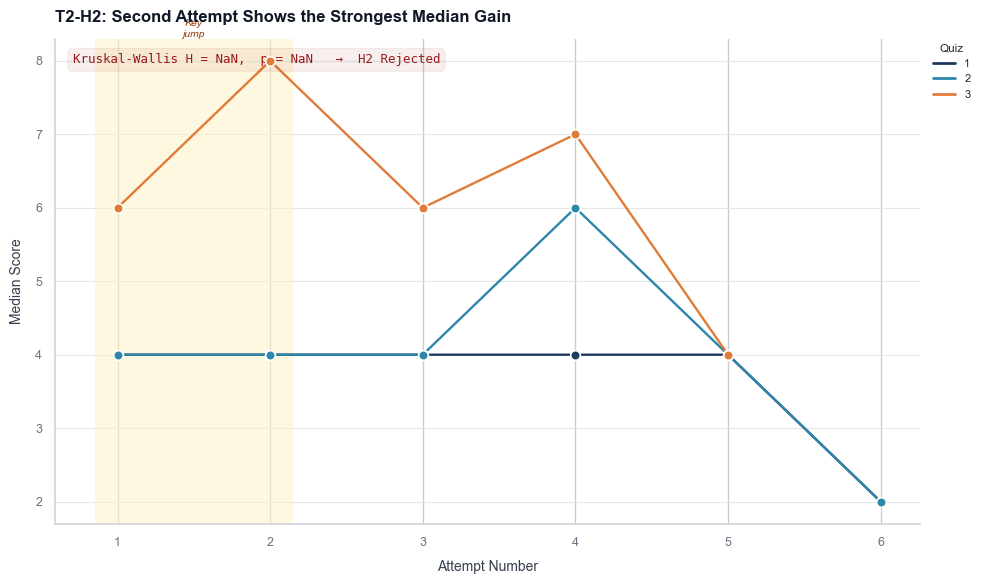

In [30]:
# ----- Task 2 - H2 -----
if "results" not in globals():
    results = []

# ── data ──────────────────────────────────────────────────────────
h2_plot = task2_df[task2_df["attempt_no"] <= 6].copy()
h2_agg  = h2_plot.groupby(["quiz", "attempt_no"])["grade"].median().reset_index()

per_quiz = (
    task2_df[task2_df["attempt_no"] <= 3]
    .groupby(["quiz", "attempt_no"])["grade"]
    .median()
    .unstack("attempt_no")
)
gains_12 = (per_quiz.get(2) - per_quiz.get(1)).dropna()
h2_groups = [g["grade"].values for _, g in task2_df[task2_df["attempt_no"] <= 4].groupby("attempt_no") if len(g) > 0]
h2_stat, p2 = safe_kruskal(*h2_groups) if len(h2_groups) >= 2 else (np.nan, np.nan)
consistent_jump = bool((gains_12 >= 2.0).all()) if len(gains_12) > 0 else False
verdict  = "Accepted" if (pd.notna(p2) and p2 < 0.05 and consistent_jump) else "Rejected"

# ── palette — distinct but muted, print-safe ──────────────────────────────────
COLORS = ["#1E3A5F", "#2E86AB", "#E07B39", "#6A994E", "#9B5DE5", "#C9184A",
          "#457B9D", "#F4A261", "#2A9D8F", "#E76F51"]

quizzes = sorted(h2_agg["quiz"].unique())
color_map = {q: COLORS[i % len(COLORS)] for i, q in enumerate(quizzes)}

# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for quiz in quizzes:
    d = h2_agg[h2_agg["quiz"] == quiz].sort_values("attempt_no")
    ax.plot(d["attempt_no"], d["grade"],
            color=color_map[quiz], linewidth=1.7,
            solid_capstyle="round", zorder=3)
    ax.scatter(d["attempt_no"], d["grade"],
               s=48, color=color_map[quiz],
               edgecolors="white", linewidths=1.2, zorder=4)

# ── shaded region highlighting attempt 1→2 jump ───────────────────────────────
ax.axvspan(0.85, 2.15, color="#FEF3C7", alpha=0.55, zorder=1, linewidth=0)
ax.text(1.5, ax.get_ylim()[1] if ax.get_ylim()[1] else 100,
        "Key\njump", ha="center", va="bottom",
        fontsize=7.5, color="#92400E", style="italic")

# ── grid & spines ─────────────────────────────────────────────────────────────
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D1D5DB")

# ── stat annotation ───────────────────────────────────────────────────────────
stat_str = f"{h2_stat:.3f}" if pd.notna(h2_stat) else "NaN"
p_str    = f"{p2:.2e}"      if pd.notna(p2)     else "NaN"
v_color  = "#166534" if verdict == "Accepted" else "#991B1B"

ax.text(0.02, 0.97,
        f"Kruskal-Wallis H = {stat_str},  p = {p_str}   →  H2 {verdict}",
        transform=ax.transAxes, va="top", fontsize=9,
        color=v_color, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=v_color,
                  alpha=0.07, edgecolor=v_color, linewidth=0.8))

# ── axes & labels ─────────────────────────────────────────────────────────────
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlabel("Attempt Number", fontsize=10, color="#374151", labelpad=8)
ax.set_ylabel("Median Score",   fontsize=10, color="#374151", labelpad=8)
ax.tick_params(colors="#6B7280", labelsize=9)

ax.set_title("T2-H2: Second Attempt Shows the Strongest Median Gain",
             fontsize=12, fontweight="bold", loc="left", pad=12, color="#111827")

# ── legend — outside right so it doesn't crowd the chart ─────────────────────
handles = [plt.Line2D([0], [0], color=color_map[q], linewidth=2, label=str(q))
           for q in quizzes]
ax.legend(handles=handles, title="Quiz", title_fontsize=8.5,
          fontsize=8, frameon=False,
          loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

# ── results ───────────────────────────────────────────────────────
results.append({
    "hypothesis_id": "T2-H2",
    "hypothesis": "Attempt 1->2 gain is consistently large across quizzes",
    "test": "Per-quiz median gain + Kruskal-Wallis by attempt",
    "statistic": float(h2_stat) if pd.notna(h2_stat) else np.nan,
    "p_value": float(p2)        if pd.notna(p2)     else np.nan,
    "decision": verdict
})

### Task 2 - Hypothesis 3
**Topic:** Time gap between attempts vs score improvement

C:\Users\DASUN\AppData\Local\Temp\ipykernel_24356\3232338001.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


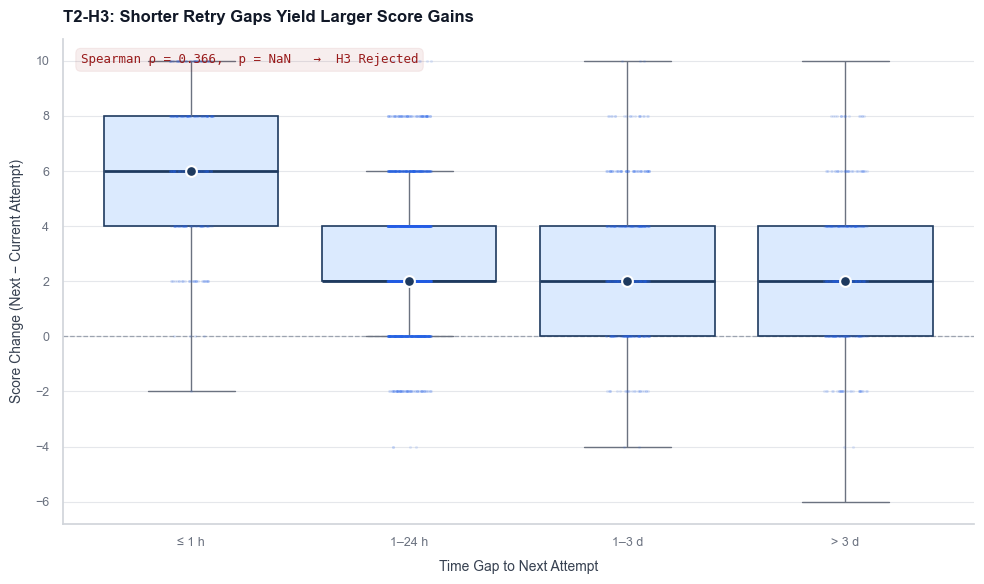

In [31]:
# ----- Task 2 - H3 -----
if "results" not in globals():
    results = []

# ── data ──────────────────────────────────────────────────────────
h3 = task2_df[["quiz", "student", "attempt_no", "start_dt", "grade"]].copy()
h3 = h3.sort_values(["quiz", "student", "attempt_no"])
h3["next_grade"] = h3.groupby(["quiz", "student"])["grade"].shift(-1)
h3["next_start"] = h3.groupby(["quiz", "student"])["start_dt"].shift(-1)
h3["delta"]      = h3["next_grade"] - h3["grade"]
h3["gap_hours"]  = (h3["next_start"] - h3["start_dt"]).dt.total_seconds() / 3600.0
h3 = h3.dropna(subset=["delta", "gap_hours"])

if len(h3) > 0:
    rho3, p3 = safe_spearmanr(h3["gap_hours"], h3["delta"])

    bins   = [-0.001, 1, 24, 72, 1e9]
    labels = ["≤ 1 h", "1–24 h", "1–3 d", "> 3 d"]
    h3["gap_bucket"] = pd.cut(h3["gap_hours"], bins=bins, labels=labels)

    verdict = "Accepted" if (pd.notna(rho3) and rho3 < 0 and pd.notna(p3) and p3 < 0.05) else "Rejected"
    v_color = "#166534" if verdict == "Accepted" else "#991B1B"

    # ── bucket-level medians for overlay ──────────────────────────────────────
    bucket_med = h3.groupby("gap_bucket", observed=True)["delta"].median()

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # zero reference line
    ax.axhline(0, color="#9CA3AF", linewidth=0.9, linestyle="--", zorder=1)

    # boxplot — clean, no default seaborn colour noise
    sns.boxplot(
        data=h3, x="gap_bucket", y="delta",
        order=labels, showfliers=False,
        boxprops=dict(facecolor="#DBEAFE", edgecolor="#1E3A5F", linewidth=1.2),
        medianprops=dict(color="#1E3A5F", linewidth=2),
        whiskerprops=dict(color="#6B7280", linewidth=1),
        capprops=dict(color="#6B7280", linewidth=1),
        ax=ax, zorder=2
    )

    # jitter strip — subdued so boxes remain readable
    sns.stripplot(
        data=h3.sample(min(4000, len(h3)), random_state=7),
        x="gap_bucket", y="delta", order=labels,
        color="#2563EB", alpha=0.12, size=2.2, jitter=True, ax=ax, zorder=3
    )

    # median dots on top
    for i, lbl in enumerate(labels):
        if lbl in bucket_med.index:
            ax.scatter(i, bucket_med[lbl], s=60, color="#1E3A5F",
                       edgecolors="white", linewidths=1.5, zorder=5)

    # ── grid & spines ─────────────────────────────────────────────────────────
    ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#D1D5DB")

    # ── stat annotation ───────────────────────────────────────────────────────
    p_str  = f"{p3:.2e}" if pd.notna(p3) else "NaN"
    ax.text(0.02, 0.97,
            f"Spearman ρ = {rho3:.3f},  p = {p_str}   →  H3 {verdict}",
            transform=ax.transAxes, va="top", fontsize=9,
            color=v_color, fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=v_color,
                      alpha=0.07, edgecolor=v_color, linewidth=0.8))

    # ── labels ────────────────────────────────────────────────────────────────
    ax.set_title("T2-H3: Shorter Retry Gaps Yield Larger Score Gains",
                 fontsize=12, fontweight="bold", loc="left", pad=12, color="#111827")
    ax.set_xlabel("Time Gap to Next Attempt", fontsize=10, color="#374151", labelpad=8)
    ax.set_ylabel("Score Change (Next − Current Attempt)", fontsize=10, color="#374151", labelpad=8)
    ax.tick_params(colors="#6B7280", labelsize=9)
    ax.set_xticklabels(labels)

    plt.tight_layout()
    plt.show()

else:
    rho3, p3 = np.nan, np.nan
    print("Task2-H3 skipped: no valid retry-gap rows (requires valid datetime for attempt timestamps).")

# ── results ───────────────────────────────────────────────────────
results.append({
    "hypothesis_id": "T2-H3",
    "hypothesis": "Longer waiting before retry is linked to smaller improvement",
    "test": "Spearman(gap_hours, next_attempt_score_delta)",
    "statistic": float(rho3) if pd.notna(rho3) else np.nan,
    "p_value": float(p3)     if pd.notna(p3)    else np.nan,
    "decision": verdict if len(h3) > 0 else "Rejected"
})

### Task 2 - Hypothesis 4
**Topic:** Saturation point for reaching high scores (8+)

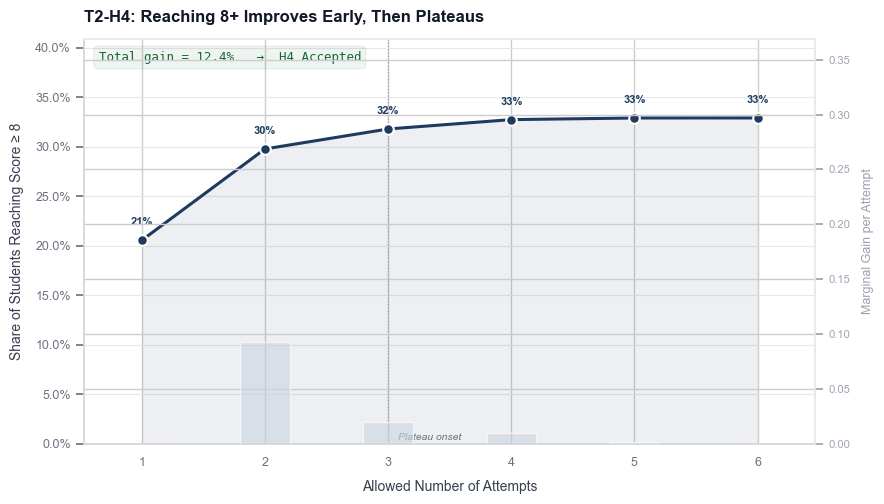

In [32]:
import matplotlib.ticker as ticker
# ----- Task 2 - H4 -----
if "results" not in globals():
    results = []

# ── data ──────────────────────────────────────────────────────────
max_attempt = int(min(6, task2_df["attempt_no"].max()))
rows = []
for k in range(1, max_attempt + 1):
    best_until_k = (
        task2_df[task2_df["attempt_no"] <= k]
        .groupby(["quiz", "student"])["grade"]
        .max()
        .reset_index(name="best_grade")
    )
    rows.append({"attempt_cap": k, "rate_ge_8": float((best_until_k["best_grade"] >= 8).mean())})
h4_curve = pd.DataFrame(rows)
h4_curve["marginal_gain"] = h4_curve["rate_ge_8"].diff()

diminishing  = bool((h4_curve["marginal_gain"].fillna(1).iloc[1:] <= h4_curve["marginal_gain"].fillna(1).iloc[1]).all())
total_gain   = h4_curve["rate_ge_8"].iloc[-1] - h4_curve["rate_ge_8"].iloc[0]
verdict      = "Accepted" if diminishing else "Rejected"
v_color      = "#166534" if verdict == "Accepted" else "#991B1B"

# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = h4_curve["attempt_cap"]
y = h4_curve["rate_ge_8"]
mg = h4_curve["marginal_gain"].fillna(0)

# ── area fill under curve ─────────────────────────────────────────────────────
ax.fill_between(x, y, alpha=0.08, color="#1E3A5F", linewidth=0, zorder=1)

# ── marginal-gain bars (secondary story) ──────────────────────────────────────
ax2 = ax.twinx()
ax2.bar(x, mg, color="#CBD5E1", width=0.4, alpha=0.6, zorder=1, label="Marginal gain")
ax2.set_ylabel("Marginal Gain per Attempt", fontsize=9, color="#9CA3AF", labelpad=8)
ax2.tick_params(colors="#9CA3AF", labelsize=8)
ax2.set_ylim(0, mg.max() * 4 if mg.max() > 0 else 1)   # keep bars visually small
for spine in ["top", "right"]:
    ax2.spines[spine].set_color("#E5E7EB")
for spine in ["left", "bottom"]:
    ax2.spines[spine].set_visible(False)

# ── main cumulative line ───────────────────────────────────────────────────────
ax.plot(x, y, color="#1E3A5F", linewidth=2.2,
        solid_capstyle="round", zorder=3)
ax.scatter(x, y, s=58, color="#1E3A5F",
           edgecolors="white", linewidths=1.5, zorder=4)

# ── per-point % labels ────────────────────────────────────────────────────────
for xi, yi in zip(x, y):
    ax.text(xi, yi + 0.013, f"{yi:.0%}",
            ha="center", va="bottom", fontsize=8, color="#1E3A5F", fontweight="bold")

# ── plateau annotation ────────────────────────────────────────────────────────
if diminishing and len(x) >= 3:
    plateau_x = float(x.iloc[2])          # gain typically flattens by attempt 3
    ax.axvline(plateau_x, color="#9CA3AF", linewidth=0.9,
               linestyle=":", zorder=2)
    ax.text(plateau_x + 0.08, ax.get_ylim()[0] + 0.02,
            "Plateau onset", fontsize=7.5, color="#6B7280", style="italic")

# ── grid & spines (primary axis) ──────────────────────────────────────────────
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D1D5DB")

# ── stat annotation ───────────────────────────────────────────────────────────
ax.text(0.02, 0.97,
        f"Total gain = {total_gain:.1%}   →  H4 {verdict}",
        transform=ax.transAxes, va="top", fontsize=9,
        color=v_color, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=v_color,
                  alpha=0.07, edgecolor=v_color, linewidth=0.8))

# ── labels ────────────────────────────────────────────────────────────────────
ax.set_title("T2-H4: Reaching 8+ Improves Early, Then Plateaus",
             fontsize=12, fontweight="bold", loc="left", pad=12, color="#111827")
ax.set_xlabel("Allowed Number of Attempts", fontsize=10, color="#374151", labelpad=8)
ax.set_ylabel("Share of Students Reaching Score ≥ 8", fontsize=10, color="#374151", labelpad=8)
ax.set_xticks(list(range(1, max_attempt + 1)))
ax.set_ylim(0, min(1.0, y.max() + 0.08))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.tick_params(colors="#6B7280", labelsize=9)

plt.tight_layout()
plt.show()

# ── results ───────────────────────────────────────────────────────
results.append({
    "hypothesis_id": "T2-H4",
    "hypothesis": "Most 8+ attainment happens in early retries, then plateaus",
    "test": "Monotonic rate and diminishing marginal gains",
    "statistic": float(total_gain),
    "p_value": np.nan,
    "decision": verdict
})

### Task 2 - Hypothesis 5
**Topic:** Cross-quiz learning trend in first-attempt performance

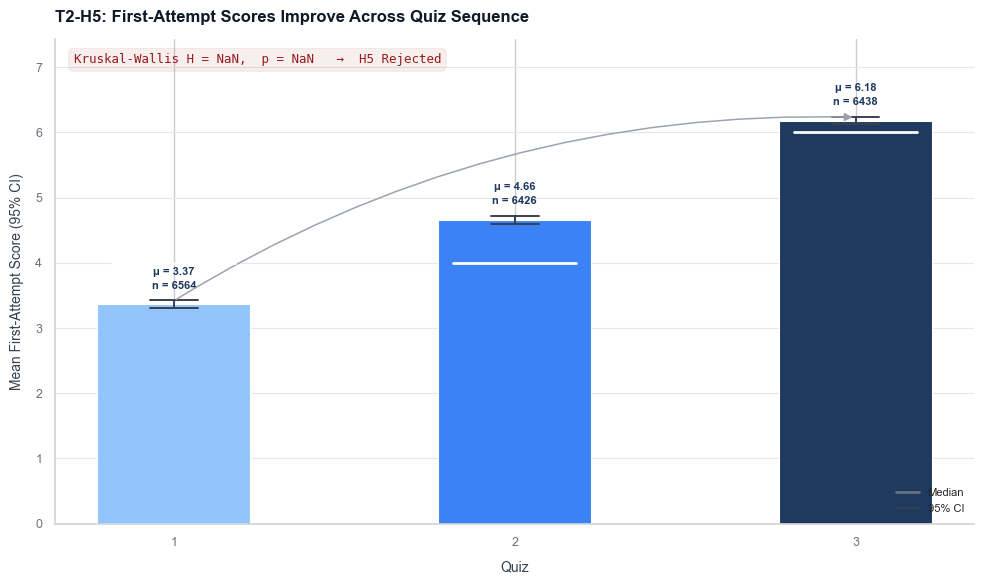

Task 2 hypothesis summary:


,hypothesis_id,decision,statistic,p_value
0,T2-H1,Rejected,-0.571747,NaN
1,T2-H2,Rejected,NaN,NaN
2,T2-H3,Rejected,0.366477,NaN
3,T2-H4,Accepted,0.123636,NaN
4,T2-H5,Rejected,NaN,NaN


,hypothesis_id,hypothesis,test,statistic,p_value,decision
0,T2-H1,Lower first-attempt score is associated with m...,"Spearman(first_grade, total_attempts)",-0.571747,NaN,Rejected
1,T2-H2,Attempt 1->2 gain is consistently large across...,Per-quiz median gain + Kruskal-Wallis by attempt,NaN,NaN,Rejected
2,T2-H3,Longer waiting before retry is linked to small...,"Spearman(gap_hours, next_attempt_score_delta)",0.366477,NaN,Rejected
3,T2-H4,"Most 8+ attainment happens in early retries, t...",Monotonic rate and diminishing marginal gains,0.123636,NaN,Accepted
4,T2-H5,Students perform better on first attempts in l...,Kruskal-Wallis across quizzes + monotonic medians,NaN,NaN,Rejected


In [33]:
# ----- Task 2 - H5 -----
if "results" not in globals():
    results = []

# ── data ──────────────────────────────────────────────────────────
first_attempt = task2_df[task2_df["attempt_no"] == 1].copy()
h5_summary    = first_attempt.groupby("quiz")["grade"].agg(["mean", "median", "count"]).reset_index()

h5_groups  = [g["grade"].values for _, g in first_attempt.groupby("quiz") if len(g) > 0]
h5_stat, p5 = safe_kruskal(*h5_groups) if len(h5_groups) >= 2 else (np.nan, np.nan)
increasing  = bool(h5_summary["median"].is_monotonic_increasing) if len(h5_summary) > 1 else False
verdict     = "Accepted" if (pd.notna(p5) and p5 < 0.05 and increasing) else "Rejected"
v_color     = "#166534" if verdict == "Accepted" else "#991B1B"

quizzes     = h5_summary["quiz"].tolist()
means       = h5_summary["mean"].tolist()
medians     = h5_summary["median"].tolist()
counts      = h5_summary["count"].tolist()

# 95% CI half-widths via bootstrap mean ± 1.96 * SE
ci_low, ci_high = [], []
for _, g in first_attempt.groupby("quiz"):
    se = g["grade"].sem()
    m  = g["grade"].mean()
    ci_low.append(m - 1.96 * se)
    ci_high.append(m + 1.96 * se)

# ── colour: light→dark blue to reinforce progression ─────────────────────────
BAR_COLORS = ["#93C5FD", "#3B82F6", "#1E3A5F"]   # quiz 1 → quiz 3
if len(quizzes) != 3:                              # fallback for non-3-quiz data
    BAR_COLORS = ["#3B82F6"] * len(quizzes)

x = np.arange(len(quizzes))

# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# bars
bars = ax.bar(x, means, width=0.45, color=BAR_COLORS,
              edgecolor="white", linewidth=0.8, zorder=2)

# 95% CI error bars
for i, (lo, hi, m) in enumerate(zip(ci_low, ci_high, means)):
    ax.plot([x[i], x[i]], [lo, hi], color="#374151", linewidth=1.4, zorder=3)
    ax.plot([x[i] - 0.07, x[i] + 0.07], [lo, lo], color="#374151", linewidth=1.4, zorder=3)
    ax.plot([x[i] - 0.07, x[i] + 0.07], [hi, hi], color="#374151", linewidth=1.4, zorder=3)

# median tick inside each bar
for i, med in enumerate(medians):
    ax.plot([x[i] - 0.18, x[i] + 0.18], [med, med],
            color="white", linewidth=2, zorder=4, solid_capstyle="round")

# mean + n labels above each bar
y_max = max(ci_high) if ci_high else max(means)
for i, (m, n, hi) in enumerate(zip(means, counts, ci_high)):
    ax.text(x[i], hi + 0.15, f"μ = {m:.2f}\nn = {n}",
            ha="center", va="bottom", fontsize=8,
            color="#1E3A5F", fontweight="bold", linespacing=1.5)

# progression arrow across bar tops (visual reinforcement)
if len(means) >= 2 and increasing:
    ax.annotate("", xy=(x[-1], means[-1] + 0.05),
                xytext=(x[0], means[0] + 0.05),
                arrowprops=dict(arrowstyle="-|>", color="#9CA3AF",
                                lw=1.1, connectionstyle="arc3,rad=-0.15"))

# ── grid & spines ─────────────────────────────────────────────────────────────
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D1D5DB")

# ── stat annotation ───────────────────────────────────────────────────────────
stat_str = f"{h5_stat:.3f}" if pd.notna(h5_stat) else "NaN"
p_str    = f"{p5:.2e}"      if pd.notna(p5)      else "NaN"
ax.text(0.02, 0.97,
        f"Kruskal-Wallis H = {stat_str},  p = {p_str}   →  H5 {verdict}",
        transform=ax.transAxes, va="top", fontsize=9,
        color=v_color, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=v_color,
                  alpha=0.07, edgecolor=v_color, linewidth=0.8))

# ── legend for white median tick ──────────────────────────────────────────────
median_patch = plt.Line2D([0], [0], color="#6B7280", linewidth=2, label="Median")
ci_patch     = plt.Line2D([0], [0], color="#374151", linewidth=1.4, label="95% CI")
ax.legend(handles=[median_patch, ci_patch], fontsize=8,
          frameon=False, loc="lower right")

# ── labels ────────────────────────────────────────────────────────────────────
ax.set_title("T2-H5: First-Attempt Scores Improve Across Quiz Sequence",
             fontsize=12, fontweight="bold", loc="left", pad=12, color="#111827")
ax.set_xlabel("Quiz", fontsize=10, color="#374151", labelpad=8)
ax.set_ylabel("Mean First-Attempt Score (95% CI)", fontsize=10, color="#374151", labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels([str(q) for q in quizzes])
ax.tick_params(colors="#6B7280", labelsize=9)
ax.set_ylim(0, y_max + 1.2)

plt.tight_layout()
plt.show()

# ── results ───────────────────────────────────────────────────────
results.append({
    "hypothesis_id": "T2-H5",
    "hypothesis": "Students perform better on first attempts in later quizzes",
    "test": "Kruskal-Wallis across quizzes + monotonic medians",
    "statistic": float(h5_stat) if pd.notna(h5_stat) else np.nan,
    "p_value": float(p5)        if pd.notna(p5)       else np.nan,
    "decision": verdict
})

task2_results = pd.DataFrame(results)
print("Task 2 hypothesis summary:")
display(task2_results[["hypothesis_id", "decision", "statistic", "p_value"]])
task2_results